Este notebook realiza un análisis profundo de los clusters obtenidos en el proceso de detección de anomalías marítimas. El objetivo es caracterizar cada grupo, identificar patrones dominantes, estudiar su relación con anomalías potencialmente reales y extraer conclusiones interpretables

## Imports

In [1]:
import os
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive

from IPython.display import display

plt.style.use("default")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

## Carga de datos

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
base_path = "/content/drive/MyDrive/TFG/"

input_path = os.path.join(base_path, "results/clustering/anomaly_clusters_interpreted.csv")

df = pd.read_csv(input_path)

df.shape


(7069, 27)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7069 entries, 0 to 7068
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   turning_rate_max        7069 non-null   float64
 1   delta_course_mean       7069 non-null   float64
 2   cluster_kmeans          7069 non-null   int64  
 3   lof_score               7069 non-null   float64
 4   ae_score                7069 non-null   float64
 5   anomaly_type            7069 non-null   object 
 6   low_distance_flag       7069 non-null   int64  
 7   ais_gap                 7069 non-null   float64
 8   ship_type               7069 non-null   object 
 9   potential_real_anomaly  7069 non-null   int64  
 10  speed_mean              7069 non-null   float64
 11  high_speed_flag         7069 non-null   int64  
 12  duration                7069 non-null   float64
 13  course_instability      7069 non-null   float64
 14  speed_max               7069 non-null   

In [6]:
df

,turning_rate_max,delta_course_mean,cluster_kmeans,lof_score,ae_score,anomaly_type,low_distance_flag,ais_gap,ship_type,potential_real_anomaly,speed_mean,high_speed_flag,duration,course_instability,speed_max,delta_course_max,hybrid_score,turning_rate_mean,pca_1,is_synthetic,erratic_motion_flag,distance_km,cluster_hdbscan,avg_speed_kmh,turning_intensity,slow_motion,pca_2
0,0.1061,4.7750,0,3.3883,1.0630,speed_anomaly,1,1.0000,Special_Craft,0,0.0000,1,720.0000,14.3250,0.0000,19.1000,0.2639,0.0265,1.9174,1,0,0.0034,-1,0.0172,0.0265,1,-0.9420
1,2.5681,87.1625,6,1.0216,0.0005,normal,1,3.5013,Passenger,0,0.0333,0,691.0000,90.0375,0.1000,177.2000,0.1269,1.1737,-1.1519,0,1,0.0000,4,0.0000,0.6936,1,2.4932
2,0.9711,94.7250,1,1.2354,0.0002,normal,1,2.1333,Special_Craft,0,0.0400,0,727.0000,80.0750,0.1000,174.8000,0.1269,0.5235,-0.2471,0,0,0.0022,7,0.0110,0.3735,1,1.9226
3,1.1330,18.1571,1,1.0803,0.0008,normal,1,2.1333,Special_Craft,0,0.3375,0,780.0000,95.1429,0.7000,113.3000,0.1026,0.1898,0.4444,0,0,0.0954,7,0.4403,0.1614,1,0.6156
4,2.5793,55.9000,4,1.1906,0.0001,normal,0,2.4522,Special_Craft,0,4.2000,0,841.0000,99.5000,5.9000,155.4000,0.1634,0.8952,-3.5619,0,1,1.7658,2,7.5587,0.6346,0,-0.3538
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7064,2.4362,98.1667,1,2.1276,1.2051,speed_anomaly,1,1.5182,Passenger,1,0.0734,1,890.0000,69.9333,0.2725,168.1000,0.3691,1.3487,-0.1089,1,0,0.0297,-1,0.1202,1.3307,1,1.6649
7065,0.0000,0.0000,2,1.0822,0.0001,normal,1,2.4948,Tanker,0,0.0000,0,721.0000,0.0000,0.0000,0.0000,0.0732,0.0000,1.8960,0,0,0.0078,7,0.0389,0.0000,1,-0.7555
7066,1.8081,76.3400,6,0.9926,0.0004,normal,1,3.2032,Passenger,0,0.0000,0,830.0000,102.6600,0.0000,179.0000,0.1269,0.9050,-1.0569,0,1,0.0483,4,0.2095,0.7171,1,2.3461
7067,0.5134,22.9750,1,0.9564,0.0001,normal,1,3.4592,Service,0,0.0200,0,722.0000,68.9250,0.1000,91.9000,0.0732,0.1284,0.8356,0,0,0.0097,7,0.0483,0.0490,1,0.4865


## Tamaño y distribución de clusters

In [8]:
cluster_counts = df["cluster_kmeans"].value_counts().sort_index()
cluster_pct = df["cluster_kmeans"].value_counts(normalize=True).sort_index()

cluster_summary = pd.DataFrame({
    "count": cluster_counts,
    "percentage": (cluster_pct * 100).round(2)
})

cluster_summary

,count,percentage
cluster_kmeans,,
0,1005,14.2200
1,2216,31.3500
2,1553,21.9700
3,299,4.2300
4,998,14.1200
5,20,0.2800
6,525,7.4300
7,453,6.4100


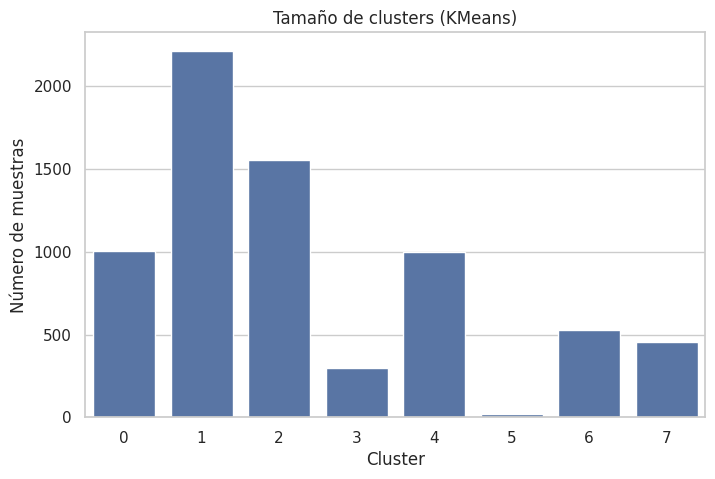

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.barplot(x=cluster_summary.index, y=cluster_summary["count"])
plt.title("Tamaño de clusters (KMeans)")
plt.xlabel("Cluster")
plt.ylabel("Número de muestras")
plt.show()

El cluster 5 representa un subconjunto extremadamente reducido de trayectorias (0.28%), lo que sugiere la presencia de comportamientos altamente atípicos dentro del dataset.

Su bajo tamaño indica que el modelo está capturando patrones muy específicos que no aparecen con frecuencia en los datos, lo cual es consistente con el objetivo de detección de anomalías.

## Análisis cluster 5

In [10]:
df_c5 = df[df["cluster_kmeans"] == 5]

print("Tamaño:", len(df_c5))
df_c5.head()

Tamaño: 20


,turning_rate_max,delta_course_mean,cluster_kmeans,lof_score,ae_score,anomaly_type,low_distance_flag,ais_gap,ship_type,potential_real_anomaly,speed_mean,high_speed_flag,duration,course_instability,speed_max,delta_course_max,hybrid_score,turning_rate_mean,pca_1,is_synthetic,erratic_motion_flag,distance_km,cluster_hdbscan,avg_speed_kmh,turning_intensity,slow_motion,pca_2
326,51.0000,64.6000,5,1.0855,0.0017,normal,0,1.3929,Tanker,0,1.4167,0,719.0000,88.4000,8.5000,153.0000,0.0540,10.3937,-6.9720,0,0,114.9681,-1,575.6373,0.4944,0,2.9422
402,119.1000,19.2769,5,1.1649,0.0044,ais_gap_anomaly,0,2.5082,Service,0,6.0714,0,829.0000,102.5231,6.8000,121.8000,0.1644,9.3081,-8.5719,1,0,113.0594,-1,490.9674,0.2999,0,3.0171
512,140.0000,39.0167,5,1.0175,0.0015,normal,0,1.6085,Passenger,0,1.7538,0,819.0000,135.9833,22.8000,175.0000,0.1272,12.0367,-11.6459,0,1,1.3027,-1,5.7260,0.5705,0,4.8506
515,109.1000,50.4286,5,1.1135,0.0053,normal,0,1.2663,Special_Craft,0,5.6867,0,771.0000,118.7714,6.8000,169.2000,0.1280,9.9765,-9.6162,0,1,70.9332,-1,331.2041,0.8994,0,4.1041
1142,175.0000,66.9125,5,1.5198,0.0100,normal,0,6.8057,Tanker,0,2.9556,0,522.0000,108.0875,8.9000,175.0000,0.0925,23.1428,-14.1054,0,0,106.4120,-1,733.8707,0.2813,0,9.1739


In [11]:
df_c5.describe()

,turning_rate_max,delta_course_mean,cluster_kmeans,lof_score,ae_score,low_distance_flag,ais_gap,potential_real_anomaly,speed_mean,high_speed_flag,duration,course_instability,speed_max,delta_course_max,hybrid_score,turning_rate_mean,pca_1,is_synthetic,erratic_motion_flag,distance_km,cluster_hdbscan,avg_speed_kmh,turning_intensity,slow_motion,pca_2
count,20.0000,20.0000,20.0000,20.0000,20.0000,20.0000,20.0000,20.0000,20.0000,20.0000,20.0000,20.0000,20.0000,20.0000,20.0000,20.0000,20.0000,20.0000,20.0000,20.0000,20.0000,20.0000,20.0000,20.0000,20.0000
mean,118.2450,52.4622,5.0000,1.4012,0.0060,0.0500,2.3134,0.0000,4.3664,0.0000,774.7500,92.4378,9.1150,144.9000,0.1190,13.7660,-9.9218,0.1000,0.3000,69.3222,-1.0000,326.6125,0.5417,0.1000,4.9635
std,35.1682,34.6070,0.0000,0.8419,0.0064,0.2236,1.5901,0.0000,2.5863,0.0000,118.9550,27.7915,6.4077,33.8226,0.0321,8.5084,3.4253,0.3078,0.4702,57.8745,0.0000,272.0607,0.3186,0.3078,3.2450
min,51.0000,17.1769,5.0000,0.9688,0.0013,0.0000,1.1057,0.0000,0.1333,0.0000,397.0000,35.2500,0.2000,79.9000,0.0540,6.6026,-18.1912,0.0000,0.0000,0.0231,-1.0000,0.0957,0.1882,0.0000,1.5111
25%,91.1625,25.4282,5.0000,1.0816,0.0017,0.0000,1.2648,0.0000,2.6551,0.0000,760.7500,77.8603,5.9750,116.6250,0.0983,9.0421,-11.4294,0.0000,0.0000,10.7267,-1.0000,87.5082,0.2784,0.0000,2.9172
50%,109.1000,46.2050,5.0000,1.1346,0.0045,0.0000,1.5156,0.0000,4.0325,0.0000,829.0000,91.9490,6.8500,160.1000,0.1272,10.3361,-9.3462,0.0000,0.0000,71.3509,-1.0000,321.2442,0.4725,0.0000,3.4972
75%,143.5250,65.1781,5.0000,1.1981,0.0084,0.0000,2.6243,0.0000,5.8411,0.0000,832.5000,110.7585,9.1000,175.0000,0.1282,13.9491,-7.2416,0.0000,1.0000,113.5366,-1.0000,557.5935,0.7850,0.0000,5.7503
max,175.0000,124.8857,5.0000,4.7326,0.0292,1.0000,6.8057,0.0000,10.7625,0.0000,870.0000,135.9833,23.1000,179.1000,0.1658,40.5671,-3.9372,1.0000,1.0000,167.3167,-1.0000,733.8707,1.2334,1.0000,13.5602


Comparación global (media de todo el dataset)

In [12]:
numeric_cols = df.select_dtypes(include=np.number).columns

comparison = pd.DataFrame({
    "cluster_5": df_c5[numeric_cols].mean(),
    "global": df[numeric_cols].mean()
})

comparison["diff"] = comparison["cluster_5"] - comparison["global"]

comparison.sort_values("diff", ascending=False)

,cluster_5,global,diff
avg_speed_kmh,326.6125,18.1508,308.4618
turning_rate_max,118.2450,1.8836,116.3614
distance_km,69.3222,3.8905,65.4317
delta_course_max,144.9000,89.9596,54.9404
course_instability,92.4378,53.3037,39.1341
delta_course_mean,52.4622,36.7849,15.6774
turning_rate_mean,13.7660,0.5037,13.2623
speed_max,9.1150,2.7307,6.3843
pca_2,4.9635,0.0000,4.9635
speed_mean,4.3664,1.5138,2.8526


El cluster 5 presenta un comportamiento extremadamente diferenciado respecto al conjunto global, caracterizado por velocidades significativamente superiores, trayectorias más largas y cambios de rumbo muy pronunciados.

Estos resultados indican que el modelo es capaz de identificar patrones extremos desde el punto de vista físico y dinámico.

Sin embargo, este cluster no presenta anomalías potencialmente reales, lo que sugiere que dichos comportamientos, aunque atípicos, no necesariamente corresponden a situaciones relevantes desde el punto de vista operativo.

Esto pone de manifiesto una limitación del enfoque basado únicamente en detección no supervisada, ya que puede priorizar outliers extremos que no representan eventos críticos en el dominio marítimo.

## Potential anomaly

La variable potential_real_anomaly no corresponde a una etiqueta externa, sino que se define como el 5% superior de puntuaciones del modelo híbrido.

Por tanto, no representa anomalías reales verificadas, sino una aproximación basada en la propia salida del modelo.

In [13]:
pd.crosstab(df["cluster_kmeans"], df["potential_real_anomaly"], normalize="index")

potential_real_anomaly,0,1
cluster_kmeans,,
0,0.8547,0.1453
1,0.9454,0.0546
2,0.9948,0.0052
3,1.0000,0.0000
4,1.0000,0.0000
5,1.0000,0.0000
6,0.8933,0.1067
7,0.9492,0.0508


El análisis de los clusters revela que no todas las anomalías detectadas presentan la misma relevancia.

En particular, el cluster 0 concentra la mayor proporción de anomalías con puntuaciones elevadas según el modelo híbrido (14.5%), seguido del cluster 6 (10.7%).

Por el contrario, otros clusters como el 5, a pesar de presentar comportamientos extremos desde el punto de vista físico, no son considerados relevantes por el modelo.

Esto indica que el sistema no se limita a detectar outliers estadísticos, sino que discrimina entre diferentes tipos de anomalías, priorizando aquellas que presentan patrones más consistentes con comportamientos potencialmente relevantes.

## Análisis cluster 0

In [14]:
df_c0 = df[df["cluster_kmeans"] == 0]

print("Tamaño:", len(df_c0))

df_c0.describe()

Tamaño: 1005


,turning_rate_max,delta_course_mean,cluster_kmeans,lof_score,ae_score,low_distance_flag,ais_gap,potential_real_anomaly,speed_mean,high_speed_flag,duration,course_instability,speed_max,delta_course_max,hybrid_score,turning_rate_mean,pca_1,is_synthetic,erratic_motion_flag,distance_km,cluster_hdbscan,avg_speed_kmh,turning_intensity,slow_motion,pca_2
count,1005.0000,1005.0000,1005.0000,1005.0000,1005.0000,1005.0000,1005.0000,1005.0000,1005.0000,1005.0000,1005.0000,1005.0000,1005.0000,1005.0000,1005.0000,1005.0000,1005.0000,1005.0000,1005.0000,1005.0000,1005.0000,1005.0000,1005.0000,1005.0000,1005.0000
mean,0.1678,6.6106,0.0000,3.4195,1.0595,0.9950,1.3810,0.1453,0.0754,1.0000,748.8898,9.6548,0.1780,16.2654,0.2710,0.0601,1.9375,1.0000,0.0000,0.1101,3.4478,0.5101,0.0552,0.9960,-0.9732
std,0.4134,13.7898,0.0000,0.4165,0.0737,0.0704,0.6642,0.3526,0.4457,0.0000,79.0122,20.9649,0.8733,32.7933,0.0268,0.1323,0.4574,0.0000,0.0000,2.5052,6.3937,11.7094,0.1194,0.0630,0.4901
min,0.0000,0.0000,0.0000,1.6194,0.1136,0.0000,1.0000,0.0000,0.0000,1.0000,250.0000,0.0000,0.0000,0.0000,0.0700,0.0000,-0.6596,1.0000,0.0000,0.0000,-1.0000,0.0000,0.0000,0.0000,-3.2333
25%,0.0000,0.0000,0.0000,3.3816,1.0521,1.0000,1.0111,0.0000,0.0000,1.0000,719.0000,0.0000,0.0000,0.0000,0.2623,0.0000,1.9662,1.0000,0.0000,0.0059,-1.0000,0.0291,0.0000,1.0000,-1.1965
50%,0.0000,0.0000,0.0000,3.4228,1.0654,1.0000,1.0935,0.0000,0.0000,1.0000,721.0000,0.0000,0.0000,0.0000,0.2659,0.0000,2.1446,1.0000,0.0000,0.0114,-1.0000,0.0548,0.0000,1.0000,-1.1913
75%,0.1212,5.7750,0.0000,3.6468,1.0760,1.0000,1.5795,0.0000,0.0175,1.0000,810.0000,7.0800,0.1187,13.2000,0.2669,0.0498,2.1593,1.0000,0.0000,0.0218,10.0000,0.1049,0.0469,1.0000,-1.0015
max,5.4727,80.7500,0.0000,5.9866,2.2106,1.0000,6.5217,1.0000,11.4543,1.0000,1008.2740,130.4500,15.9439,144.9000,0.5225,1.0427,2.3385,1.0000,0.0000,79.0970,15.0000,370.2835,0.9245,1.0000,0.8737


In [15]:
numeric_cols = df.select_dtypes(include=np.number).columns

comparison_0 = pd.DataFrame({
    "cluster_0": df_c0[numeric_cols].mean(),
    "global": df[numeric_cols].mean()
})

comparison_0["diff"] = comparison_0["cluster_0"] - comparison_0["global"]

comparison_0.sort_values("diff", ascending=False)

,cluster_0,global,diff
pca_1,1.9375,0.0000,1.9375
ae_score,1.0595,0.2161,0.8435
high_speed_flag,1.0000,0.1863,0.8137
is_synthetic,1.0000,0.3314,0.6686
slow_motion,0.9960,0.7995,0.1965
low_distance_flag,0.9950,0.8116,0.1835
hybrid_score,0.2710,0.1292,0.1418
potential_real_anomaly,0.1453,0.0501,0.0952
erratic_motion_flag,0.0000,0.1337,-0.1337
turning_intensity,0.0552,0.3166,-0.2614


El cluster 0 concentra la mayor proporción de anomalías priorizadas por el modelo híbrido (14.5%), lo que indica que representa uno de los patrones más relevantes dentro del sistema.

A diferencia de otros clusters caracterizados por valores extremos, este grupo presenta velocidades y desplazamientos relativamente bajos, junto con una baja variabilidad en la trayectoria.

Sin embargo, la activación simultánea de múltiples indicadores (como high_speed_flag, low_distance_flag y slow_motion) sugiere la presencia de inconsistencias en el comportamiento registrado.

Este tipo de patrones podría estar asociado a errores en la señal AIS, comportamientos anómalos no físicos o incluso posibles manipulaciones, lo que explica su alta puntuación en el modelo híbrido.

Estos resultados ponen de manifiesto que el modelo es capaz de identificar anomalías relevantes más allá de los outliers extremos, capturando patrones sutiles pero potencialmente críticos desde el punto de vista operativo.

In [16]:
df_c0["anomaly_type"].value_counts(normalize=True)

,proportion
anomaly_type,
speed_anomaly,0.9990
close_approach,0.0010


El análisis del cluster 0 revela que está compuesto casi exclusivamente por anomalías de tipo speed_anomaly (99.9%), lo que indica que el modelo ha identificado un patrón altamente consistente.

A pesar de que las variables de velocidad y desplazamiento presentan valores bajos en términos absolutos, la activación de indicadores como high_speed_flag sugiere una discrepancia entre la información reportada y el comportamiento real de la embarcación.

Este tipo de inconsistencia puede estar asociada a errores en la transmisión de datos AIS, problemas de calibración o incluso posibles manipulaciones del sistema.

Estos resultados evidencian que el modelo es capaz de detectar anomalías semánticas o lógicas, más allá de simples valores extremos, lo cual es especialmente relevante en entornos reales donde no todas las anomalías se manifiestan mediante outliers evidentes.

## Análisis cluster 6

In [17]:
df_c6 = df[df["cluster_kmeans"] == 6]

print("Tamaño:", len(df_c6))

df_c6.describe()

Tamaño: 525


,turning_rate_max,delta_course_mean,cluster_kmeans,lof_score,ae_score,low_distance_flag,ais_gap,potential_real_anomaly,speed_mean,high_speed_flag,duration,course_instability,speed_max,delta_course_max,hybrid_score,turning_rate_mean,pca_1,is_synthetic,erratic_motion_flag,distance_km,cluster_hdbscan,avg_speed_kmh,turning_intensity,slow_motion,pca_2
count,525.0000,525.0000,525.0000,525.0000,525.0000,525.0000,525.0000,525.0000,525.0000,525.0000,525.0000,525.0000,525.0000,525.0000,525.0000,525.0000,525.0000,525.0000,525.0000,525.0000,525.0000,525.0000,525.0000,525.0000,525.0000
mean,2.7310,69.2045,6.0000,3.8497,0.1333,0.9829,2.5656,0.1067,0.3114,0.1124,817.8970,98.2835,1.2912,167.4150,0.1424,0.9577,-1.1804,0.2686,1.0000,0.7184,3.2724,3.1153,0.7434,0.9105,1.9554
std,1.7946,13.7599,0.0000,9.5031,0.3408,0.1299,1.1025,0.3090,0.7153,0.3161,190.2795,12.3304,2.5071,11.2958,0.0799,0.2808,0.5295,0.4436,0.0000,6.2236,1.5860,26.8508,0.1741,0.2858,0.5163
min,0.7260,36.2250,6.0000,0.9715,0.0001,0.0000,1.0067,0.0000,0.0000,0.0000,399.0000,82.2857,0.0000,125.4000,0.0537,0.4335,-3.4398,0.0000,1.0000,0.0000,-1.0000,0.0000,0.5291,0.0000,-0.5619
25%,2.1159,58.5778,6.0000,1.0135,0.0003,1.0000,1.7484,0.0000,0.0000,0.0000,747.0000,88.4889,0.0000,161.7000,0.1025,0.7686,-1.1915,0.0000,1.0000,0.0089,3.0000,0.0417,0.6001,1.0000,1.7594
50%,2.3886,69.6933,6.0000,1.0511,0.0005,1.0000,2.4865,0.0000,0.0231,0.0000,813.0000,95.6571,0.1000,169.9000,0.1269,0.9151,-1.0483,0.0000,1.0000,0.0172,4.0000,0.0774,0.7048,1.0000,2.0801
75%,2.5657,79.8000,6.0000,1.2627,0.0033,1.0000,3.2032,0.0000,0.3396,0.0000,849.0000,105.5700,1.1000,175.9000,0.1269,1.0850,-0.8918,1.0000,1.0000,0.0883,4.0000,0.4366,0.8315,1.0000,2.2963
max,19.3250,129.9165,6.0000,52.6489,1.8132,1.0000,9.1050,1.0000,10.2790,1.0000,1520.0277,155.0649,15.3957,222.9951,0.4622,2.6962,-0.2922,1.0000,1.0000,80.5738,5.0000,345.3147,1.3169,1.0000,3.4593


In [18]:
comparison_6 = pd.DataFrame({
    "cluster_6": df_c6[numeric_cols].mean(),
    "global": df[numeric_cols].mean()
})

comparison_6["diff"] = comparison_6["cluster_6"] - comparison_6["global"]

comparison_6.sort_values("diff", ascending=False)

,cluster_6,global,diff
delta_course_max,167.4150,89.9596,77.4554
course_instability,98.2835,53.3037,44.9799
delta_course_mean,69.2045,36.7849,32.4197
duration,817.8970,801.6466,16.2503
cluster_kmeans,6.0000,2.3528,3.6472
pca_2,1.9554,0.0000,1.9554
erratic_motion_flag,1.0000,0.1337,0.8663
turning_rate_max,2.7310,1.8836,0.8473
turning_rate_mean,0.9577,0.5037,0.4541
turning_intensity,0.7434,0.3166,0.4268


El cluster 6 presenta un patrón claramente diferenciado, caracterizado por elevados valores de cambio de rumbo (delta_course_max), inestabilidad de trayectoria (course_instability) y activación sistemática del indicador de movimiento errático (erratic_motion_flag).

A diferencia de los outliers extremos, este cluster no se caracteriza por velocidades elevadas ni grandes desplazamientos, sino por la irregularidad en la trayectoria seguida.

Este tipo de comportamiento puede estar asociado a maniobras inusuales, navegación errática o situaciones operativamente relevantes, lo que explica su mayor proporción de anomalías priorizadas por el modelo híbrido (10.7%).

Estos resultados refuerzan la capacidad del sistema para detectar anomalías dinámicas significativas, más allá de simples valores extremos.

## Visualizaciones

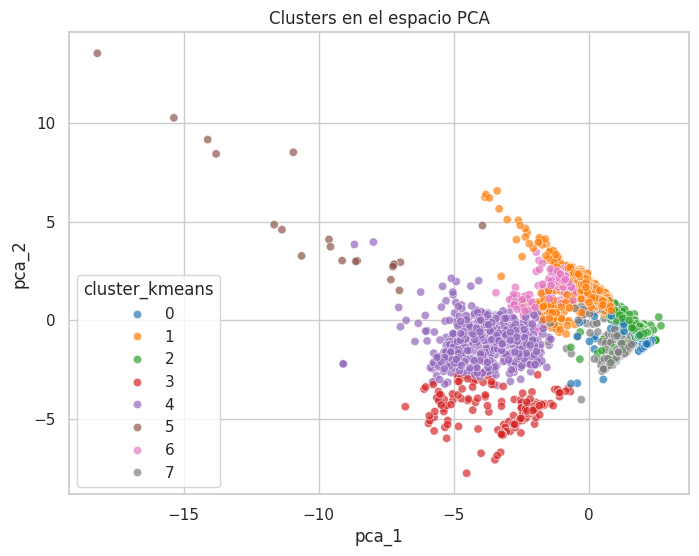

In [19]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="pca_1",
    y="pca_2",
    hue="cluster_kmeans",
    palette="tab10",
    alpha=0.7
)
plt.title("Clusters en el espacio PCA")
plt.show()

Los clusters 0 y 7 presentan solapamiento en el espacio PCA, lo que indica que sus patrones no son completamente separables en una proyección lineal de baja dimensión.

En datos reales, las anomalías no forman grupos perfectamente separados, sino que existe continuidad entre comportamientos. El clustering permite identificar tendencias y patrones dominantes, aunque con cierto solapamiento.

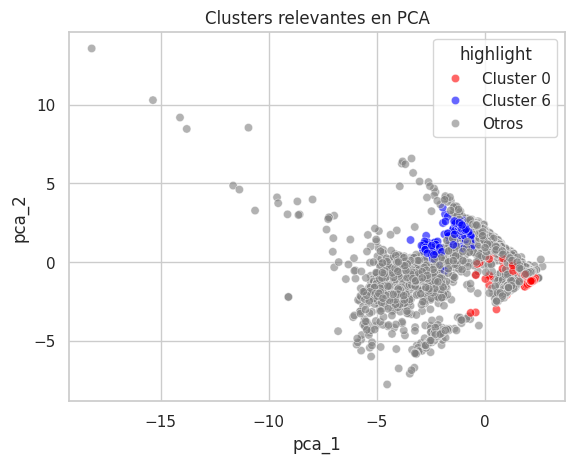

In [20]:
df["highlight"] = df["cluster_kmeans"].apply(
    lambda x: "Cluster 0" if x==0 else ("Cluster 6" if x==6 else "Otros")
)

sns.scatterplot(
    data=df,
    x="pca_1",
    y="pca_2",
    hue="highlight",
    palette={"Cluster 0":"red","Cluster 6":"blue","Otros":"grey"},
    alpha=0.6
)
plt.title("Clusters relevantes en PCA")
plt.show()

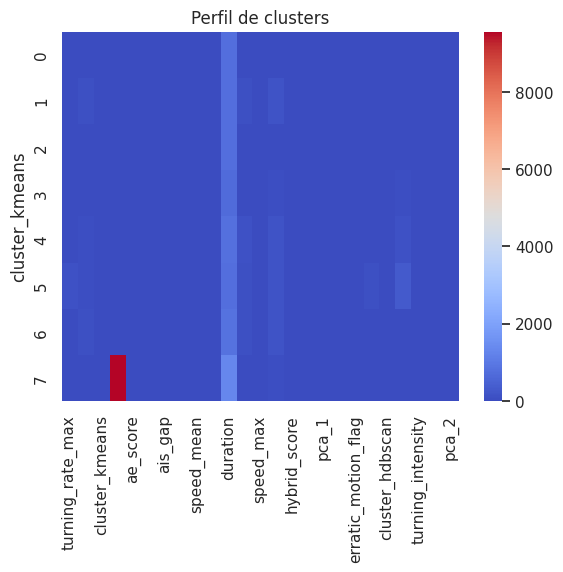

In [21]:
cluster_means = df.groupby("cluster_kmeans")[numeric_cols].mean()

sns.heatmap(cluster_means, cmap="coolwarm")
plt.title("Perfil de clusters")
plt.show()

El heatmap permite analizar simultáneamente múltiples variables y revela diferencias estructurales entre clusters en términos de magnitud y combinación de características.

Se observa que el cluster 7 presenta valores extremadamente elevados en ciertas variables, destacando claramente respecto al resto, lo que sugiere la presencia de outliers o comportamientos muy específicos que dominan su perfil medio.

Por otro lado, clusters como el 6 presentan valores elevados en variables relacionadas con la dinámica angular, como turning_intensity, delta_course_mean y course_instability, lo que confirma su asociación con trayectorias erráticas.

En contraste, el cluster 0 presenta valores bajos en la mayoría de variables físicas (velocidad, distancia, cambios de rumbo), pero valores relativamente altos en variables derivadas del modelo (ae_score, hybrid_score), lo que indica que su anomalía no es física sino estructural o lógica.

Matemáticamente, el heatmap muestra que los clusters no solo se diferencian por una variable aislada, sino por vectores de características en espacios multidimensionales, lo que justifica que algunos grupos puedan solaparse en PCA pero estar bien separados en el espacio original.

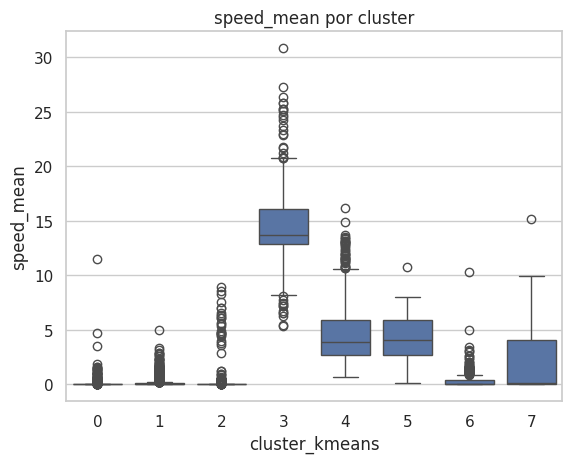

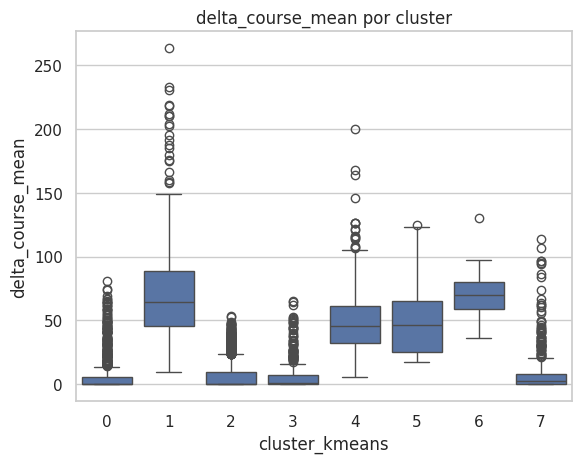

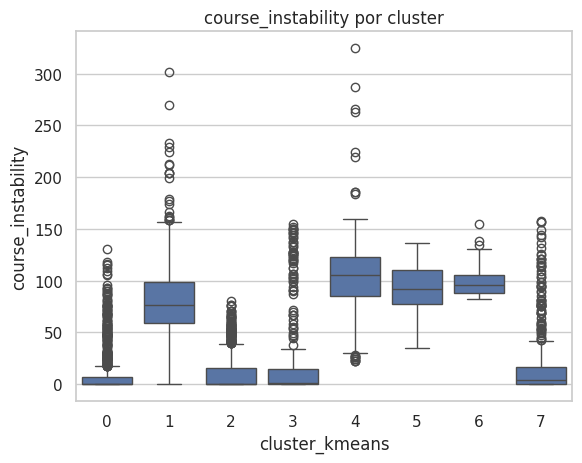

In [22]:
features = ["speed_mean", "delta_course_mean", "course_instability"]

for f in features:
    sns.boxplot(data=df, x="cluster_kmeans", y=f)
    plt.title(f"{f} por cluster")
    plt.show()

Los diagramas de caja muestran una clara heterogeneidad en la distribución de las variables entre clusters, con diferencias que no solo son cualitativas sino también cuantitativas.

En particular, se observa que el cluster 3 presenta valores de speed_mean significativamente superiores, con una mediana en torno a 14–15, mientras que la mayoría de clusters (0, 1, 2, 6, 7) tienen medianas cercanas a 0–1. Esto supone una diferencia de más de un orden de magnitud, indicando un régimen de movimiento completamente distinto.

En cuanto a delta_course_mean, el cluster 6 presenta una mediana elevada (~70) frente a valores cercanos a 0–10 en clusters como el 0, 2 o 3, lo que refleja cambios de rumbo mucho más pronunciados. Esta diferencia también se observa en course_instability, donde clusters como el 4, 5 y 6 presentan medianas cercanas a 90–110, frente a valores inferiores a 10 en clusters más estables.

Además, la amplitud de las cajas (IQR) y la presencia de outliers indican que algunos clusters, como el 1 o el 4, presentan alta variabilidad interna, mientras que otros, como el 0, están más concentrados, lo que sugiere patrones más consistentes.

En conjunto, los boxplots evidencian que los clusters capturan regímenes dinámicos claramente diferenciados, aunque con cierta superposición en los valores bajos, especialmente entre los clusters 0, 2 y 7.

## Conclusión

El análisis combinado de los boxplots y el heatmap permite concluir que el clustering identifica distintos regímenes de comportamiento en los datos AIS, caracterizados por diferencias significativas en variables clave tanto en magnitud como en variabilidad.

Desde un punto de vista cuantitativo, se observan diferencias de orden de magnitud en variables como la velocidad (speed_mean) y los cambios de rumbo (delta_course_mean), lo que evidencia la existencia de patrones claramente diferenciados. Sin embargo, estas diferencias no son uniformes en todas las dimensiones, lo que genera solapamientos parciales entre clusters en proyecciones de baja dimensión como PCA.

En particular, se identifican tres tipos principales de comportamiento:

- Anomalías físicas extremas, con valores muy elevados en variables dinámicas (ej. cluster 5 o 7)
- Anomalías dinámicas, caracterizadas por trayectorias erráticas (cluster 6)
- Anomalías de consistencia, con valores físicos bajos pero puntuaciones altas en modelos (cluster 0)

Este resultado pone de manifiesto que el espacio de anomalías no es discreto, sino continuo y multidimensional, donde distintos tipos de comportamientos pueden compartir ciertas características y diferir en otras.

En consecuencia, el clustering proporciona una segmentación útil pero no suficiente por sí sola, lo que justifica la necesidad de un sistema de ranking posterior que permita priorizar anomalías en función de su relevancia operativa.